# Age, Gender & Hair Identification System 

This final revision keeps the project structure but fixes the errors found in the previous run.

- 224×224 input
- age regression with stronger age loss weighting
- safe age MAE plotting
- no test-set validation during fine-tuning
- separate hair EfficientNetB0
- hair images are validated and re-saved as clean JPEGs before TensorFlow training
- hair pipeline uses `decode_jpeg` on the cleaned files
- dropout, BatchNormalization, augmentation, EarlyStopping, ReduceLROnPlateau and ModelCheckpoint
- final 20–30 hair-based gender rule
- GUI included


## 1. Imports and project configuration


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, confusion_matrix

from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

UTKFACE_PATH = "/Users/nenavathdigambar/Documents/machine learning/UTKFace"
LONG_HAIR_PATH = "/Users/nenavathdigambar/Documents/machine learning/Hair Length Dataset/Long Hair"
SHORT_HAIR_PATH = "/Users/nenavathdigambar/Documents/machine learning/Hair Length Dataset/Short Hair"

PROJECT_DIR = "/Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

AGE_GENDER_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_age_gender.keras")
HAIR_MODEL_PATH = os.path.join(MODEL_DIR, "efficientnetb0_hair_length.keras")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("UTKFace exists:", os.path.exists(UTKFACE_PATH))
print("Long Hair exists:", os.path.exists(LONG_HAIR_PATH))
print("Short Hair exists:", os.path.exists(SHORT_HAIR_PATH))


TensorFlow: 2.18.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
UTKFace exists: True
Long Hair exists: True
Short Hair exists: True


## 2. Prepare the UTKFace age/gender dataframe

The supplied notebook extracted age and gender directly from the UTKFace filename.


In [2]:
# Collect image paths
utk_files = [
    os.path.join(UTKFACE_PATH, f)
    for f in os.listdir(UTKFACE_PATH)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

records = []

for img_path in utk_files:
    filename = os.path.basename(img_path)

    try:
        parts = filename.split("_")
        age = int(parts[0])
        gender = int(parts[1])
    except (ValueError, IndexError):
        continue

    if 0 <= age <= 100 and gender in (0, 1):
        records.append({
            "image_path": img_path,
            "filename": filename,
            "age": age,
            "gender": gender
        })

df = pd.DataFrame(records)

print("Total valid images:", len(df))
display(df.head())
print("\nGender distribution:")
display(df["gender"].value_counts().sort_index())
print("\nAge summary:")
display(df["age"].describe())


Total valid images: 23687


,image_path,filename,age,gender
0,/Users/nenavathdigambar/Documents/machine lear...,9_1_2_20161219204347420.jpg.chip.jpg,9,1
1,/Users/nenavathdigambar/Documents/machine lear...,36_0_1_20170117163203851.jpg.chip.jpg,36,0
2,/Users/nenavathdigambar/Documents/machine lear...,86_1_0_20170120225751953.jpg.chip.jpg,86,1
3,/Users/nenavathdigambar/Documents/machine lear...,26_1_0_20170116171048641.jpg.chip.jpg,26,1
4,/Users/nenavathdigambar/Documents/machine lear...,1_1_2_20161219154612988.jpg.chip.jpg,1,1



Gender distribution:


gender
0    12386
1    11301
Name: count, dtype: int64


Age summary:


count    23687.000000
mean        33.235910
std         19.764349
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        100.000000
Name: age, dtype: float64

## 3. Check the age and gender distribution

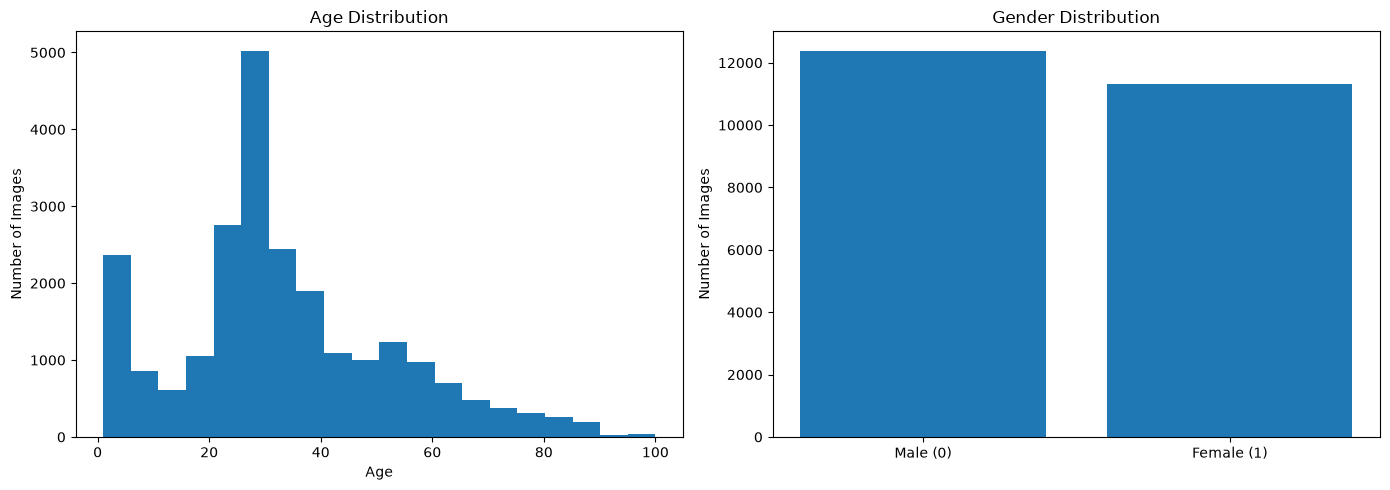

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=20)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Images")

gender_counts = df["gender"].value_counts().sort_index()
axes[1].bar(["Male (0)", "Female (1)"], gender_counts.values)
axes[1].set_title("Gender Distribution")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()


## 4. Train / validation / test split

The original notebook used a train/test split. This version keeps a separate validation set so callbacks do not tune directly on the final test set.


In [4]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["gender"]
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["gender"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 18949
Validation: 2369
Test: 2369


## 5. UTKFace image loading pipeline

Images stay in normal 0–255 RGB format. Age targets are scaled to 0–1 for more stable regression.


In [5]:
def load_utk_image(path, age, gender):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    age_scaled = tf.cast(age, tf.float32) / 100.0
    gender = tf.cast(gender, tf.float32)
    return image, {"age": age_scaled, "gender": gender}

def make_utk_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].values,
        dataframe["age"].values.astype(np.float32),
        dataframe["gender"].values.astype(np.float32)
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_utk_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_utk_dataset(train_df, True)
val_ds = make_utk_dataset(val_df, False)
test_ds = make_utk_dataset(test_df, False)
print("UTKFace pipelines ready.")


UTKFace pipelines ready.


2026-08-11 11:45:16.211297: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-11 11:45:16.211431: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-11 11:45:16.211434: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1786428916.211719   13858 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1786428916.211980   13858 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 6. Data augmentation for age/gender

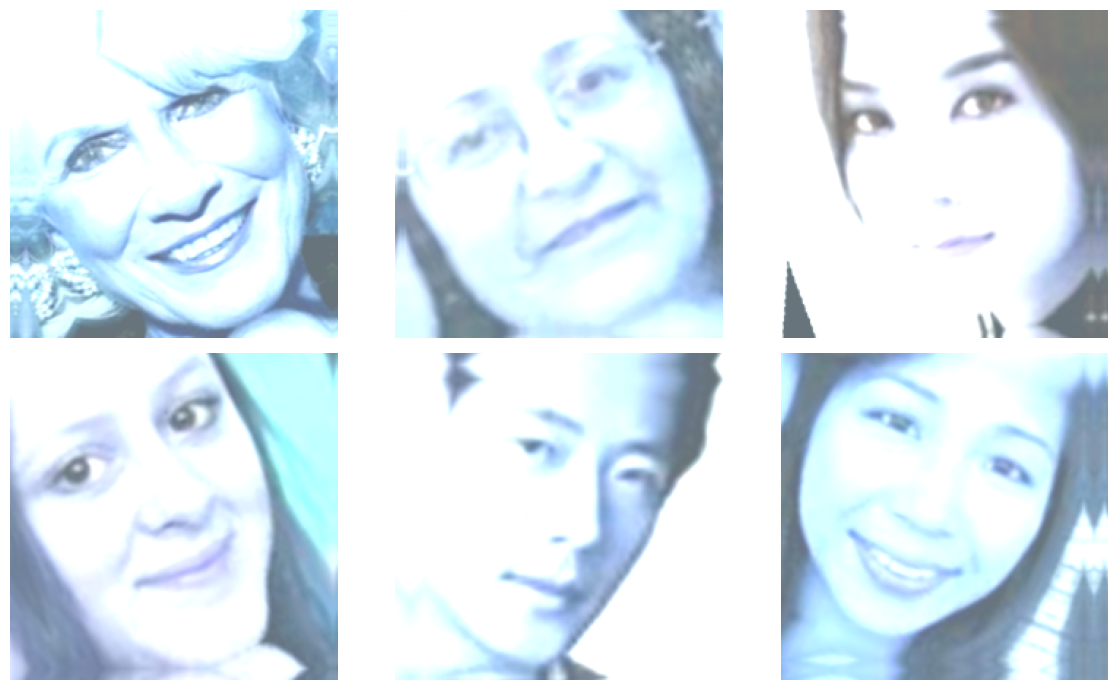

In [6]:
age_gender_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomContrast(0.10),
    ],
    name="age_gender_augmentation"
)

# Visualize a few augmented examples
sample_batch = next(iter(train_ds))
sample_images = sample_batch[0][:6]

plt.figure(figsize=(12, 7))

for i in range(6):
    augmented = age_gender_augmentation(
        tf.expand_dims(sample_images[i], axis=0),
        training=True
    )[0]

    # VGG preprocess_input is not directly display-friendly.
    # Convert approximately back to RGB for visualization.
    img = augmented.numpy()
    img = img[..., ::-1]
    img = img + np.array([103.939, 116.779, 123.68])
    img = np.clip(img / 255.0, 0, 1)

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Build age + gender model

 The model uses ImageNet transfer learning, augmentation, Batch Normalization, Dropout and two prediction branches.


In [7]:
# ============================================================
# VGG16 AGE + GENDER MODEL
# Requested neural-network structure
# ============================================================

vggnet = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vggnet.trainable = False

input_layer = Input(
    shape=(224, 224, 3),
    name="image"
)

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="age_gender_augmentation")

x = augmentation(input_layer)

# VGG16 feature extractor
output = vggnet(x, training=False)

# User-requested structure
flatten = Flatten()(output)

# Shared dropout before the two branches
shared = Dropout(0.30)(flatten)

# ---------------- AGE BRANCH ----------------
dense1 = Dense(
    512,
    activation="relu",
    name="age_dense1"
)(shared)

dense1 = BatchNormalization(
    name="age_batchnorm1"
)(dense1)

dense1 = Dropout(
    0.50,
    name="age_dropout1"
)(dense1)

dense3 = Dense(
    512,
    activation="relu",
    name="age_dense2"
)(dense1)

dense3 = BatchNormalization(
    name="age_batchnorm2"
)(dense3)

dense3 = Dropout(
    0.40,
    name="age_dropout2"
)(dense3)

output1 = Dense(
    1,
    activation="linear",
    name="age"
)(dense3)

# ---------------- GENDER BRANCH ----------------
dense2 = Dense(
    512,
    activation="relu",
    name="gender_dense1"
)(shared)

dense2 = BatchNormalization(
    name="gender_batchnorm1"
)(dense2)

dense2 = Dropout(
    0.50,
    name="gender_dropout1"
)(dense2)

dense4 = Dense(
    512,
    activation="relu",
    name="gender_dense2"
)(dense2)

dense4 = BatchNormalization(
    name="gender_batchnorm2"
)(dense4)

dense4 = Dropout(
    0.40,
    name="gender_dropout2"
)(dense4)

output2 = Dense(
    1,
    activation="sigmoid",
    name="gender"
)(dense4)

age_gender_model = Model(
    inputs=input_layer,
    outputs=[output1, output2],
    name="VGG16_Age_Gender"
)

age_gender_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    loss_weights={
        "age": 1.0,
        "gender": 1.0
    },
    metrics={
        "age": [
            keras.metrics.MeanAbsoluteError(name="mae")
        ],
        "gender": [
            keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    }
)

age_gender_model.summary()


Model: "VGG16_Age_Gender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_gender_augment… │ (None, 224, 224,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ age_gender_augme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25088)     │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_dense1 (Dense)  │ (None, 512)       │ 12,845,568 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_dense1       │ (None, 512)       │ 12,845,568 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_batchnorm1      │ (None, 512)       │      2,048 │ age_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_batchnorm1   │ (None, 512)       │      2,048 │ gender_dense1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_dropout1        │ (None, 512)       │          0 │ age_batchnorm1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_dropout1     │ (None, 512)       │          0 │ gender_batchnorm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_dense2 (Dense)  │ (None, 512)       │    262,656 │ age_dropout1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_dense2       │ (None, 512)       │    262,656 │ gender_dropout1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_batchnorm2      │ (None, 512)       │      2,048 │ age_dense2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_batchnorm2   │ (None, 512)       │      2,048 │ gender_dense2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_dropout2        │ (None, 512)       │          0 │ age_batchnorm2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_dropout2     │ (None, 512)       │          0 │ gender_batchnorm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        513 │ age_dropout2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        513 │ gender_dropout2[

 Total params: 40,940,354 (156.18 MB)

 Trainable params: 26,221,570 (100.03 MB)

 Non-trainable params: 14,718,784 (56.15 MB)

## 8. Callbacks for the age/gender model

In [8]:
age_gender_checkpoint = ModelCheckpoint(
    AGE_GENDER_MODEL_PATH,
    monitor="val_gender_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

age_gender_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

age_gender_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

age_gender_callbacks = [
    age_gender_checkpoint,
    age_gender_early_stop,
    age_gender_reduce_lr
]


## 9. Stage 1

Run 10 epochs first. The validation metrics should improve rather than remain around random gender accuracy and ~20-year age error.


In [9]:
history_age_gender = age_gender_model.fit(
    train_ds, validation_data=val_ds, epochs=10, callbacks=age_gender_callbacks
)


Epoch 1/10


/opt/anaconda3/envs/seniorapp/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-11 11:45:18.442191: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - age_loss: 1.0191 - age_mae: 1.0192 - gender_accuracy: 0.7801 - gender_loss: 0.5042 - loss: 1.5230
Epoch 1: val_gender_accuracy improved from None to 0.87336, saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_age_gender.keras

Epoch 1: finished saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_age_gender.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 384s 643ms/step - age_loss: 1.0191 - age_mae: 1.0192 - gender_accuracy: 0.7801 - gender_loss: 0.5042 - loss: 1.5230 - val_age_loss: 0.1768 - val_age_mae: 0.1790 - val_gender_accuracy: 0.8734 - val_gender_loss: 0.3073 - val_loss: 0.4886 - learning_rate: 1.0000e-04
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - age_loss: 0.7827 - age_mae: 0.7831 - gender_accuracy: 0.8262 - gender_loss: 0.4133 - loss: 1.1963
Epoch 2: val_gender_accuracy improved from 0.87336 to 0.87970, saving m

## 10. Plot age/gender training history

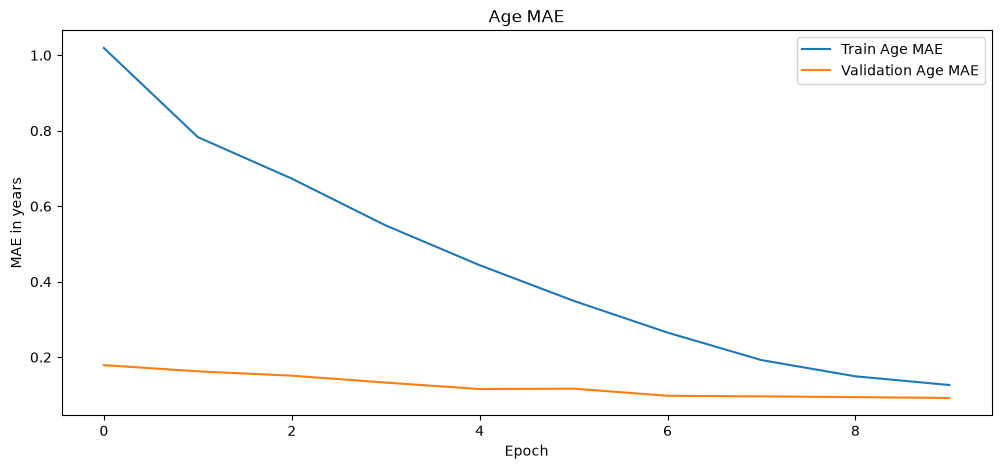

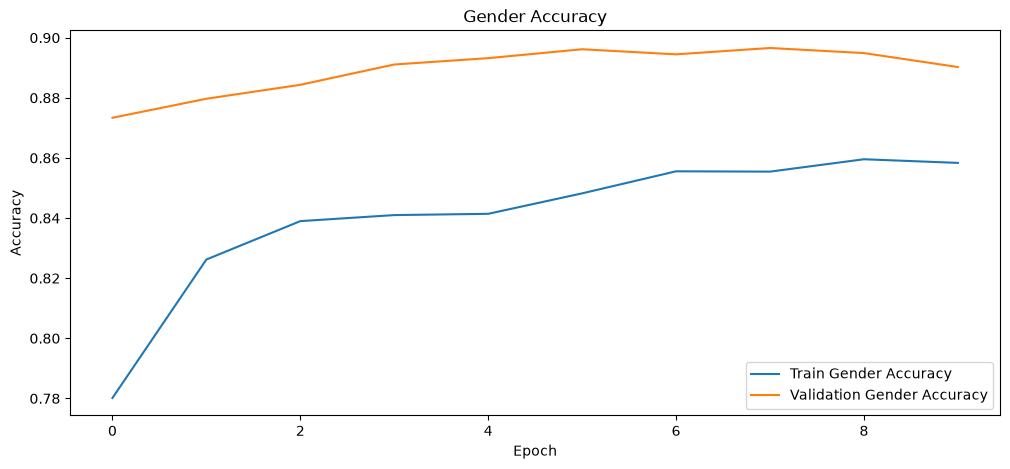

In [10]:
def plot_age_gender_history(history):
    h = history.history

    if "age_mae" in h and "val_age_mae" in h:
        plt.figure(figsize=(12, 5))
        plt.plot(h["age_mae"], label="Train Age MAE")
        plt.plot(h["val_age_mae"], label="Validation Age MAE")
        plt.title("Age MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE in years")
        plt.legend()
        plt.show()

    if "gender_accuracy" in h and "val_gender_accuracy" in h:
        plt.figure(figsize=(12, 5))
        plt.plot(h["gender_accuracy"], label="Train Gender Accuracy")
        plt.plot(h["val_gender_accuracy"], label="Validation Gender Accuracy")
        plt.title("Gender Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()


plot_age_gender_history(history_age_gender)


## 11. Stage 2 — fine-tune


In [11]:
# ============================================================
# VGG16 FINE-TUNING
# ============================================================

vggnet.trainable = True

# Freeze most VGG16 layers and fine-tune only the final
# convolutional block.
for layer in vggnet.layers[:-4]:
    layer.trainable = False

# VGG16 has no BatchNormalization layers, but keep this
# safeguard so the notebook remains robust if the backbone
# is changed later.
for layer in vggnet.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

age_gender_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    loss_weights={
        "age": 1.0,
        "gender": 1.0
    },
    metrics={
        "age": [
            keras.metrics.MeanAbsoluteError(name="mae")
        ],
        "gender": [
            keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    }
)

history_age_gender_ft = age_gender_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=age_gender_callbacks
)


Epoch 1/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - age_loss: 0.1129 - age_mae: 0.1129 - gender_accuracy: 0.8714 - gender_loss: 0.3143 - loss: 0.4274
Epoch 1: val_gender_accuracy improved from 0.89658 to 0.90249, saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_age_gender.keras

Epoch 1: finished saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_age_gender.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 430s 722ms/step - age_loss: 0.1129 - age_mae: 0.1129 - gender_accuracy: 0.8714 - gender_loss: 0.3143 - loss: 0.4274 - val_age_loss: 0.0844 - val_age_mae: 0.0851 - val_gender_accuracy: 0.9025 - val_gender_loss: 0.2333 - val_loss: 0.3207 - learning_rate: 1.0000e-05
Epoch 2/15
593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - age_loss: 0.1085 - age_mae: 0.1086 - gender_accuracy: 0.8786 - gender_loss: 0.2935 - loss: 0.4007
Epoch 2: val_gender_accuracy improved from 0.90249 to 0.9

In [12]:
# Removed: duplicate fine-tuning block that incorrectly used test_ds for validation.


## 12. Evaluate the age/gender model


In [13]:
age_gender_model = keras.models.load_model(
    AGE_GENDER_MODEL_PATH,
    compile=False
)

age_gender_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    loss_weights={
        "age": 1.0,
        "gender": 1.0
    },
    metrics={
        "age": [
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ],
        "gender": [
            keras.metrics.BinaryAccuracy(
                name="accuracy"
            )
        ]
    }
)

results = age_gender_model.evaluate(
    test_ds,
    return_dict=True
)

print("\nAge + Gender Test Results:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - age_loss: 0.0769 - age_mae: 0.0767 - gender_accuracy: 0.9266 - gender_loss: 0.1819 - loss: 0.2591

Age + Gender Test Results:
age_loss: 0.0769
age_mae: 0.0767
gender_accuracy: 0.9266
gender_loss: 0.1819
loss: 0.2591


In [14]:
age_predictions = []
gender_predictions = []
true_ages = []
true_genders = []

for images_batch, labels_batch in test_ds:
    age_pred, gender_pred = age_gender_model.predict(images_batch, verbose=0)
    age_predictions.extend(age_pred.reshape(-1) * 100.0)
    gender_predictions.extend(gender_pred.reshape(-1))
    true_ages.extend(labels_batch["age"].numpy() * 100.0)
    true_genders.extend(labels_batch["gender"].numpy())

age_predictions = np.array(age_predictions)
gender_predictions = (np.array(gender_predictions) >= 0.5).astype(int)
true_ages = np.array(true_ages)
true_genders = np.array(true_genders).astype(int)

print(f"Age MAE: {mean_absolute_error(true_ages, age_predictions):.2f} years")
print(f"Gender Accuracy: {accuracy_score(true_genders, gender_predictions):.4f}")
print(classification_report(true_genders, gender_predictions, target_names=["Male", "Female"]))
print(confusion_matrix(true_genders, gender_predictions))


Age MAE: 7.67 years
Gender Accuracy: 0.9266
              precision    recall  f1-score   support

        Male       0.94      0.92      0.93      1239
      Female       0.92      0.93      0.92      1130

    accuracy                           0.93      2369
   macro avg       0.93      0.93      0.93      2369
weighted avg       0.93      0.93      0.93      2369

[[1143   96]
 [  78 1052]]


2026-08-11 15:00:07.770133: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 13. Hair dataset preparation

Expected directory structure:

```text
Hair Length Dataset/
├── Long Hair/
└── Short Hair/
```

The label convention used here is:

- `Long Hair` = **1**
- `Short Hair` = **0**

This convention is used consistently in training, evaluation and the GUI.

In [15]:
import os
import shutil

In [16]:
# Clean every hair image before TensorFlow sees it.
# This fixes the previous: Unknown image file format error.

clean_root = os.path.join(
    PROJECT_DIR,
    "clean_hair_dataset"
)

if os.path.exists(clean_root):
    shutil.rmtree(clean_root)

clean_long = os.path.join(
    clean_root,
    "Long_Hair"
)

clean_short = os.path.join(
    clean_root,
    "Short_Hair"
)

os.makedirs(
    clean_long,
    exist_ok=True
)

os.makedirs(
    clean_short,
    exist_ok=True
)

In [17]:
import os

PROJECT_DIR = "/Users/nenavathdigambar/Documents/machine learning/age_gender_hair_VGG16_project"

REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

os.makedirs(
    REPORT_DIR,
    exist_ok=True
)

print("REPORT_DIR:", REPORT_DIR)

REPORT_DIR: /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_VGG16_project/reports


In [18]:
# Clean every hair image before TensorFlow sees it.
# This fixes the previous: Unknown image file format error.
clean_root = os.path.join(PROJECT_DIR, "clean_hair_dataset")
if os.path.exists(clean_root):
    shutil.rmtree(clean_root)
clean_long = os.path.join(clean_root, "Long_Hair")
clean_short = os.path.join(clean_root, "Short_Hair")
os.makedirs(clean_long, exist_ok=True)
os.makedirs(clean_short, exist_ok=True)

def clean_folder(source, destination, label, name):
    valid, bad = [], []
    files = [os.path.join(source, f) for f in os.listdir(source) if os.path.isfile(os.path.join(source, f))]
    for i, src_path in enumerate(files):
        try:
            with Image.open(src_path) as img:
                img.load()
                rgb = img.convert("RGB")
                dst_path = os.path.join(destination, f"{name.replace(' ', '_')}_{i:06d}.jpg")
                rgb.save(dst_path, "JPEG", quality=95)
            valid.append({"image_path": dst_path, "hair_label": label, "hair_name": name, "original_path": src_path})
        except Exception as e:
            bad.append({"original_path": src_path, "hair_label": label, "hair_name": name, "error": str(e)})
    return valid, bad

long_valid, long_bad = clean_folder(LONG_HAIR_PATH, clean_long, 1, "Long Hair")
short_valid, short_bad = clean_folder(SHORT_HAIR_PATH, clean_short, 0, "Short Hair")
hair_df = pd.DataFrame(long_valid + short_valid)
bad_hair_df = pd.DataFrame(long_bad + short_bad)
hair_df.to_csv(os.path.join(REPORT_DIR, "clean_hair_dataset.csv"), index=False)
bad_hair_df.to_csv(os.path.join(REPORT_DIR, "invalid_hair_images.csv"), index=False)
print("Valid hair images:", len(hair_df))
print("Invalid/skipped source images:", len(bad_hair_df))
display(hair_df["hair_name"].value_counts())
assert len(hair_df) > 0, "No valid hair images found after cleaning."


Valid hair images: 2289
Invalid/skipped source images: 1


hair_name
Long Hair     1237
Short Hair    1052
Name: count, dtype: int64

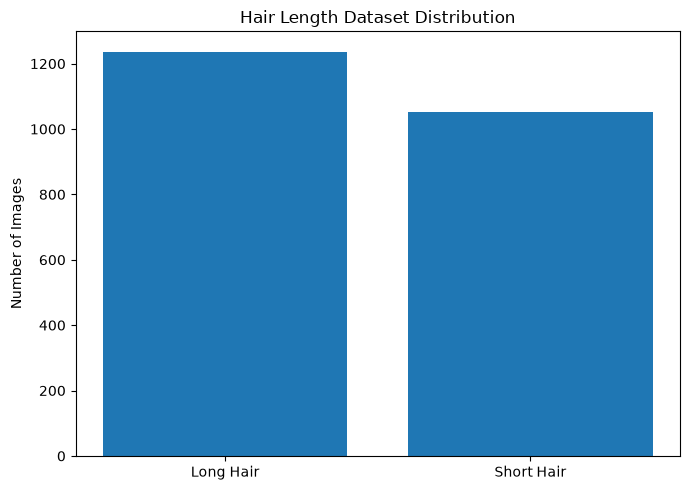

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = hair_df["hair_name"].value_counts()
ax.bar(counts.index, counts.values)
ax.set_title("Hair Length Dataset Distribution")
ax.set_ylabel("Number of Images")

plt.tight_layout()
plt.show()


## 14. Split the hair dataset

In [20]:
hair_train_df, hair_temp_df = train_test_split(
    hair_df, test_size=0.20, random_state=SEED, stratify=hair_df["hair_label"]
)
hair_val_df, hair_test_df = train_test_split(
    hair_temp_df, test_size=0.50, random_state=SEED, stratify=hair_temp_df["hair_label"]
)
hair_train_df = hair_train_df.reset_index(drop=True)
hair_val_df = hair_val_df.reset_index(drop=True)
hair_test_df = hair_test_df.reset_index(drop=True)
print("Hair train:", len(hair_train_df))
print("Hair validation:", len(hair_val_df))
print("Hair test:", len(hair_test_df))


Hair train: 1831
Hair validation: 229
Hair test: 229


## 15. Hair image pipeline and augmentation

In [21]:
def load_hair_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_hair_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].values,
        dataframe["hair_label"].values.astype(np.float32)
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_hair_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

hair_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15)
], name="hair_augmentation")

hair_train_ds = make_hair_dataset(hair_train_df, True)
hair_val_ds = make_hair_dataset(hair_val_df, False)
hair_test_ds = make_hair_dataset(hair_test_df, False)


## 16. Build the second transfer-learning CNN for hair length

In [22]:
# def build_hair_model():
#     backbone = EfficientNetB0(
#         include_top=False, weights="imagenet", input_shape=(128, 128, 3)
#     )
#     backbone.trainable = False

#     inputs = layers.Input(shape=(128, 128, 3), name="hair_image")
#     x = hair_augmentation(inputs)
#     x = backbone(x, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.50)(x)
#     x = layers.Dense(128, activation="relu")(x)
#     x = layers.Dropout(0.30)(x)
#     output = layers.Dense(1, activation="sigmoid", name="hair")(x)

#     model = Model(inputs, output, name="EfficientNetB0_Hair_Length")
#     return model, backbone

# hair_model, hair_backbone = build_hair_model()
# hair_model.compile(
#     optimizer=Adam(1e-3),
#     loss="binary_crossentropy",
#     metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
# )
# hair_model.summary()


from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow import keras


IMG_SIZE = (224, 224)


hair_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.10),
    keras.layers.RandomZoom(0.10),
    keras.layers.RandomTranslation(0.05, 0.05),
    keras.layers.RandomContrast(0.10)
], name="hair_augmentation")


# ============================================================
# EFFICIENTNETB0 HAIR MODEL
# ============================================================

hair_backbone = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

hair_backbone.trainable = False


inputs = Input(
    shape=(224, 224, 3),
    name="hair_image"
)

x = hair_augmentation(inputs)

x = hair_backbone(
    x,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = BatchNormalization()(x)

x = Dropout(
    0.5
)(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(
    0.3
)(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="hair"
)(x)


hair_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_Hair_Length"
)


hair_model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        keras.metrics.AUC(
            name="auc"
        )
    ]
)


hair_model.summary()


Model: "EfficientNetB0_Hair_Length"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hair_image (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hair_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hair (Dense)                    │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,556 (16.83 MB)

 Trainable params: 361,473 (1.38 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [23]:
for images, labels in hair_train_ds.take(1):
    print("Hair batch shape:", images.shape)
    print("Labels shape:", labels.shape)

Hair batch shape: (32, 224, 224, 3)
Labels shape: (32,)


2026-08-11 15:00:20.306165: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 17. Hair model callbacks

In [24]:
hair_checkpoint = ModelCheckpoint(
    HAIR_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

hair_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

hair_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


In [25]:
history_hair = hair_model.fit(
    hair_train_ds, validation_data=hair_val_ds, epochs=10, callbacks=[
        hair_checkpoint, hair_early_stop, hair_reduce_lr
    ]
)


Epoch 1/10


/opt/anaconda3/envs/seniorapp/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8039 - auc: 0.8807 - loss: 0.5407
Epoch 1: val_accuracy improved from None to 0.88210, saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_hair_length.keras

Epoch 1: finished saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_hair_length.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 291ms/step - accuracy: 0.8039 - auc: 0.8807 - loss: 0.5407 - val_accuracy: 0.8821 - val_auc: 0.9372 - val_loss: 0.3150 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.8427 - auc: 0.9214 - loss: 0.4067
Epoch 2: val_accuracy improved from 0.88210 to 0.90830, saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models/efficientnetb0_hair_length.keras

Epoch 2: finished saving model to /Users/nenavathdigambar/Documents/machine learning/age_gender_hair_project/models

# Duplicate heading retained intentionally; no code is executed in this cell.


## 19. Plot hair model training history

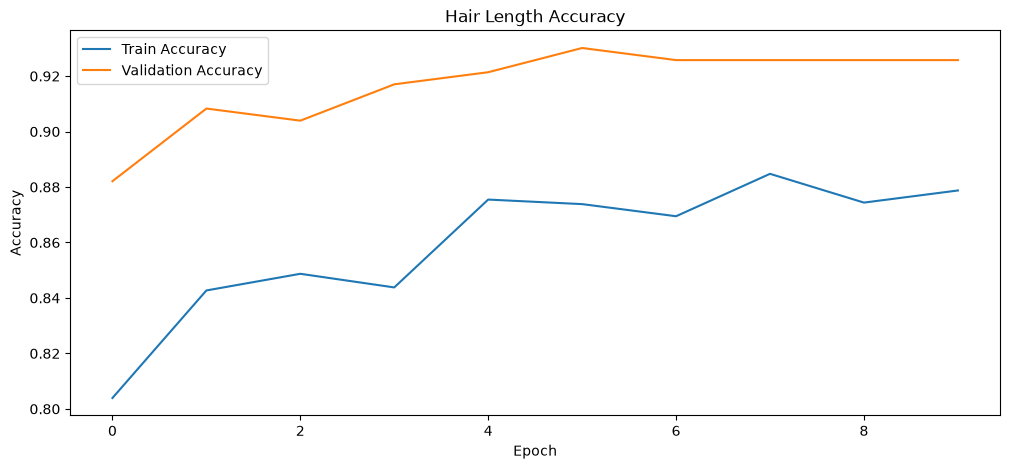

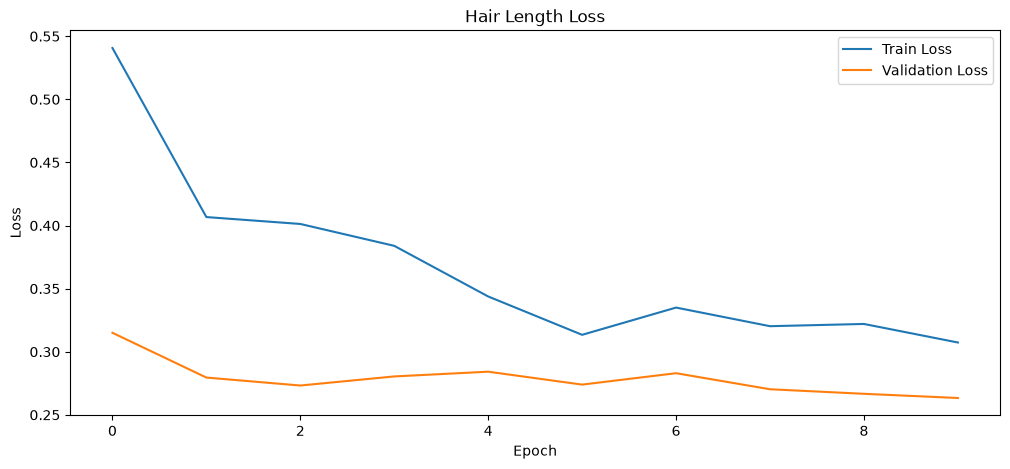

In [26]:
h = history_hair.history

if "accuracy" in h and "val_accuracy" in h:
    plt.figure(figsize=(12, 5))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Validation Accuracy")
    plt.title("Hair Length Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

if "loss" in h and "val_loss" in h:
    plt.figure(figsize=(12, 5))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.title("Hair Length Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


## 20. Fine-tune later EfficientNetB0 layers for hair length


In [27]:
for layer in hair_backbone.layers:
    layer.trainable = False

for layer in hair_backbone.layers[-60:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

hair_model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
)

hair_fine_tune_history = hair_model.fit(
    hair_train_ds, validation_data=hair_val_ds, epochs=15, callbacks=[
        hair_checkpoint, hair_early_stop, hair_reduce_lr
    ]
)


Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8777 - auc: 0.9486 - loss: 0.3059
Epoch 1: val_accuracy did not improve from 0.93013
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 434ms/step - accuracy: 0.8777 - auc: 0.9486 - loss: 0.3059 - val_accuracy: 0.9258 - val_auc: 0.9619 - val_loss: 0.2627 - learning_rate: 1.0000e-05
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8848 - auc: 0.9520 - loss: 0.2925
Epoch 2: val_accuracy did not improve from 0.93013
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 388ms/step - accuracy: 0.8848 - auc: 0.9520 - loss: 0.2925 - val_accuracy: 0.9258 - val_auc: 0.9618 - val_loss: 0.2635 - learning_rate: 1.0000e-05
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8951 - auc: 0.9587 - loss: 0.2738
Epoch 3: val_accuracy did not improve from 0.93013
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 379ms/step - accuracy: 0.8951 - auc: 0.9587 - loss: 0.2738 - val_accuracy: 0.9170 - val_auc: 0.9632 - val_loss: 0.2588 - learning_rate: 1.0000e-05
Epoch 4/15
58

## 21. Evaluate the hair model

In [28]:
hair_model = keras.models.load_model(HAIR_MODEL_PATH)
hair_results = hair_model.evaluate(hair_test_ds, return_dict=True)
for key, value in hair_results.items():
    print(f"{key}: {value:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.9520 - auc: 0.9931 - loss: 0.1121
accuracy: 0.9520
auc: 0.9931
loss: 0.1121


In [29]:
hair_probs = []
hair_true = []
for images_batch, labels_batch in hair_test_ds:
    probs = hair_model.predict(images_batch, verbose=0).reshape(-1)
    hair_probs.extend(probs)
    hair_true.extend(labels_batch.numpy())

hair_pred = (np.array(hair_probs) >= 0.5).astype(int)
hair_true = np.array(hair_true).astype(int)
print("Hair Accuracy:", accuracy_score(hair_true, hair_pred))
print(classification_report(hair_true, hair_pred, target_names=["Short Hair", "Long Hair"]))
print(confusion_matrix(hair_true, hair_pred))


Hair Accuracy: 0.9519650655021834
              precision    recall  f1-score   support

  Short Hair       0.94      0.96      0.95       105
   Long Hair       0.97      0.94      0.96       124

    accuracy                           0.95       229
   macro avg       0.95      0.95      0.95       229
weighted avg       0.95      0.95      0.95       229

[[101   4]
 [  7 117]]


## 22. Combined prediction logic

This is the assignment-specific rule layer.

### Rule

- If the predicted age is between **20 and 30 inclusive**:
  - Long Hair -> Female
  - Short Hair -> Male
- Otherwise:
  - use the original gender prediction from the age/gender CNN

The hair CNN therefore affects the final gender only for ages 20–30.

In [30]:
def predict_combined(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    with Image.open(image_path) as img:
        image = img.convert("RGB").resize(IMG_SIZE)
        image = np.asarray(image, dtype=np.float32)
    batch = np.expand_dims(image, 0)

    age_scaled, gender_prob = age_gender_model.predict(batch, verbose=0)
    predicted_age = float(np.clip(age_scaled[0][0] * 100.0, 0, 100))
    gender_probability = float(gender_prob[0][0])
    original_gender = "Female" if gender_probability >= 0.5 else "Male"

    hair_prob = float(hair_model.predict(batch, verbose=0)[0][0])
    hair_length = "Long Hair" if hair_prob >= 0.5 else "Short Hair"

    if 20 <= predicted_age <= 30:
        if hair_length == "Long Hair":
            final_gender = "Female"
            rule_status = f"Age {predicted_age:.0f} is in 20–30. Long Hair → Female."
        else:
            final_gender = "Male"
            rule_status = f"Age {predicted_age:.0f} is in 20–30. Short Hair → Male."
    else:
        final_gender = original_gender
        rule_status = f"Age {predicted_age:.0f} is outside 20–30. Hair rule not applied; original CNN gender retained."

    return {
        "age": predicted_age,
        "original_gender": original_gender,
        "gender_probability": gender_probability,
        "hair_length": hair_length,
        "hair_probability": hair_prob,
        "final_gender": final_gender,
        "rule_status": rule_status
    }


## 23. Test the combined prediction on one image

Change `TEST_IMAGE_PATH` to any image on your Mac before running this cell.

In [31]:
# Example:
# TEST_IMAGE_PATH = "/Users/nenavathdigambar/Documents/machine learning/UTKFace/some_image.jpg"

TEST_IMAGE_PATH = ""

if TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH):
    result = predict_combined(TEST_IMAGE_PATH)
    print(result)
else:
    print("Set TEST_IMAGE_PATH to a valid image path to test the combined model.")


Set TEST_IMAGE_PATH to a valid image path to test the combined model.


# 24. GUI — Age, Gender & Hair Identification System

The GUI is designed to resemble the supplied reference:

- dark blue header
- large image preview on the left
- Upload Image button on the right
- Prediction Results panel
- Logic Rule Status panel
- final gender shown separately from the original CNN gender


In [32]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk


# ------------------------------------------------------------
# GUI colors / fonts
# ------------------------------------------------------------

BG = "#f4f5f7"
HEADER = "#1f2c3d"
WHITE = "#ffffff"
TEXT = "#56657d"
DARK_TEXT = "#243247"
BLUE = "#245cff"
GREEN = "#00a66a"
BORDER = "#c7cbd1"


class AgeGenderHairGUI:

    def __init__(self, root):
        self.root = root

        self.root.title(
            "Age, Gender & Hair Identification System"
        )

        self.root.geometry("1500x850")
        self.root.minsize(1200, 700)
        self.root.configure(bg=BG)

        self.current_image = None
        self.current_photo = None

        self.build_gui()


    def build_gui(self):

        # ====================================================
        # HEADER
        # ====================================================

        header = tk.Frame(
            self.root,
            bg=HEADER,
            height=125
        )
        header.pack(fill="x")
        header.pack_propagate(False)

        title = tk.Label(
            header,
            text="Age, Gender & Hair Identification System",
            bg=HEADER,
            fg=WHITE,
            font=("Helvetica", 28, "bold")
        )
        title.pack(pady=(22, 5))

        subtitle = tk.Label(
            header,
            text="Exact Age Prediction & Long/Short Hair Rule Classifier (Age 20–30)",
            bg=HEADER,
            fg="#aeb9c8",
            font=("Helvetica", 15, "italic")
        )
        subtitle.pack()

        # ====================================================
        # MAIN AREA
        # ====================================================

        main = tk.Frame(
            self.root,
            bg=BG
        )
        main.pack(
            fill="both",
            expand=True,
            padx=20,
            pady=20
        )

        # Left image panel
        left = tk.Frame(
            main,
            bg=WHITE,
            highlightbackground="#222222",
            highlightthickness=1
        )
        left.pack(
            side="left",
            fill="both",
            expand=True,
            padx=(0, 10)
        )

        # Right panel
        right = tk.Frame(
            main,
            bg=WHITE,
            width=500,
            highlightbackground="#222222",
            highlightthickness=1
        )
        right.pack(
            side="right",
            fill="y",
            padx=(10, 0)
        )
        right.pack_propagate(False)

        # ====================================================
        # IMAGE AREA
        # ====================================================

        self.image_label = tk.Label(
            left,
            text="📷 Click 'Upload Image' to begin analysis",
            bg=WHITE,
            fg=TEXT,
            font=("Helvetica", 18),
            anchor="center"
        )
        self.image_label.pack(
            fill="both",
            expand=True,
            padx=15,
            pady=15
        )

        # ====================================================
        # UPLOAD BUTTON
        # ====================================================

        upload_button = tk.Button(
            right,
            text="📤 Upload Image",
            command=self.upload_image,
            bg=HEADER,
            fg=WHITE,
            activebackground="#304158",
            activeforeground=WHITE,
            font=("Helvetica", 18, "bold"),
            relief="solid",
            bd=2,
            cursor="hand2",
            height=2
        )
        upload_button.pack(
            fill="x",
            padx=25,
            pady=(25, 30)
        )

        # ====================================================
        # PREDICTION RESULTS
        # ====================================================

        results_frame = tk.LabelFrame(
            right,
            text="Prediction Results",
            bg=WHITE,
            fg=DARK_TEXT,
            font=("Helvetica", 15, "bold"),
            bd=1,
            relief="solid",
            padx=15,
            pady=15
        )
        results_frame.pack(
            fill="x",
            padx=25,
            pady=(0, 30)
        )

        self.age_value = self.add_result_row(
            results_frame,
            "Exact Age:",
            "–",
            BLUE
        )

        self.original_gender_value = self.add_result_row(
            results_frame,
            "Original Gender:",
            "–",
            TEXT
        )

        self.hair_value = self.add_result_row(
            results_frame,
            "Hair Length:",
            "–",
            TEXT
        )

        self.final_gender_value = self.add_result_row(
            results_frame,
            "Final Gender:",
            "–",
            GREEN
        )

        # ====================================================
        # LOGIC RULE STATUS
        # ====================================================

        logic_frame = tk.LabelFrame(
            right,
            text="Logic Rule Status",
            bg=WHITE,
            fg=DARK_TEXT,
            font=("Helvetica", 15, "bold"),
            bd=1,
            relief="solid",
            padx=15,
            pady=15
        )
        logic_frame.pack(
            fill="x",
            padx=25
        )

        self.logic_label = tk.Label(
            logic_frame,
            text="Select an image to see rule application.",
            bg=WHITE,
            fg=DARK_TEXT,
            font=("Helvetica", 13),
            justify="left",
            wraplength=400,
            anchor="w"
        )
        self.logic_label.pack(
            fill="x",
            pady=5
        )


    def add_result_row(self, parent, label_text, value_text, value_color):

        row = tk.Frame(
            parent,
            bg=WHITE
        )
        row.pack(
            fill="x",
            pady=8
        )

        label = tk.Label(
            row,
            text=label_text,
            bg=WHITE,
            fg=TEXT,
            font=("Helvetica", 14, "bold"),
            anchor="w"
        )
        label.pack(
            side="left"
        )

        value = tk.Label(
            row,
            text=value_text,
            bg=WHITE,
            fg=value_color,
            font=("Helvetica", 14, "bold"),
            anchor="e"
        )
        value.pack(
            side="right"
        )

        return value


    def upload_image(self):

        file_path = filedialog.askopenfilename(
            title="Select an image",
            filetypes=[
                ("Image files", "*.jpg *.jpeg *.png *.webp"),
                ("JPEG", "*.jpg *.jpeg"),
                ("PNG", "*.png"),
                ("All files", "*.*")
            ]
        )

        if not file_path:
            return

        try:
            # Display image
            image = Image.open(file_path).convert("RGB")

            self.current_image = image.copy()

            self.show_image(image)

            # Predict
            result = predict_combined(file_path)

            # Update results
            self.age_value.config(
                text=f"{result['age']:.0f}"
            )

            self.original_gender_value.config(
                text=result["original_gender"]
            )

            self.hair_value.config(
                text=result["hair_length"]
            )

            self.final_gender_value.config(
                text=result["final_gender"]
            )

            self.logic_label.config(
                text=result["rule_status"]
            )

        except Exception as e:

            messagebox.showerror(
                "Prediction Error",
                f"Could not process this image.\n\n{e}"
            )


    def show_image(self, image):

        # Available preview area
        max_width = 900
        max_height = 650

        display_image = image.copy()
        display_image.thumbnail(
            (max_width, max_height),
            Image.Resampling.LANCZOS
        )

        self.current_photo = ImageTk.PhotoImage(
            display_image
        )

        self.image_label.config(
            image=self.current_photo,
            text=""
        )


def launch_gui():
    root = tk.Tk()
    app = AgeGenderHairGUI(root)
    root.mainloop()


## 25. Launch the GUI

Run this cell only after the two model-training sections have completed and the models have been saved.

In [ ]:
launch_gui()


## Notes

### Gender encoding
UTKFace filenames use:
- `0` = Male
- `1` = Female

### Hair encoding
This notebook uses:
- `0` = Short Hair
- `1` = Long Hair

### Assignment rule
The CNN predicts the original gender first. The hair CNN is used only when the predicted age is between 20 and 30 inclusive.

### If age prediction is inaccurate
The assignment rule depends on the predicted age. Therefore an age prediction error around the 20 or 30 boundary can change whether the hair rule is activated. This is why the notebook uses augmentation, callbacks and a second fine-tuning stage instead of simply increasing the number of epochs.

### Training time
EfficientNetB0 fine-tuning can take significant time on a laptop. The notebook saves the best model after each stage, so once the `.keras` files exist you can skip the training cells and go directly to the combined prediction and GUI cells.
